# Predicting Car Selling Price

## Framing the problem

- We want to predict the selling price of a used car based on various characteristics of the car
- Performance should be measured by RMSE of predicted price vs actual price

## Importing packages

In [8]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

# Data
import kagglehub

# Utilities
import re
from itertools import product
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import TargetEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint
from sklearn.metrics import root_mean_squared_error
from sklearn.base import BaseEstimator, TransformerMixin


# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn import svm

## Getting the data

### Getting the data

In [9]:
# Download latest version
path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")

# print("Path to dataset files:", path)

In [10]:
car_data = pd.read_csv(path + "/car details v4.csv")
car_data.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [11]:
car_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   str    
 1   Model               2059 non-null   str    
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   str    
 6   Transmission        2059 non-null   str    
 7   Location            2059 non-null   str    
 8   Color               2059 non-null   str    
 9   Owner               2059 non-null   str    
 10  Seller Type         2059 non-null   str    
 11  Engine              1979 non-null   str    
 12  Max Power           1979 non-null   str    
 13  Max Torque          1979 non-null   str    
 14  Drivetrain          1923 non-null   str    
 15  Length              1995 non-null   float64
 16  Width            

Some columns have null values we will need to handle later.

In [12]:
car_data.describe()

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.059000e+03,2059.000000,2.059000e+03,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000
mean,1.702992e+06,2016.425449,5.422471e+04,4280.860652,1767.991980,1591.735338,5.306266,52.002210
std,2.419881e+06,3.363564,5.736172e+04,442.458507,135.265825,136.073956,0.822170,15.110198
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,4.849990e+05,2014.000000,2.900000e+04,3985.000000,1695.000000,1485.000000,5.000000,41.250000
50%,8.250000e+05,2017.000000,5.000000e+04,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,1.925000e+06,2019.000000,7.200000e+04,4629.000000,1831.500000,1675.000000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


### Digging into the categorical attributes

Notice there are a few dozen null values for many of the columns. Let's look at the categorical attributes to get a better sense of their possible values.

In [13]:
car_data["Make"].value_counts()

Make
Maruti Suzuki    440
Hyundai          349
Mercedes-Benz    171
Honda            158
Toyota           132
Audi             127
BMW              121
Mahindra         119
Tata              57
Volkswagen        50
Ford              48
Renault           43
Skoda             40
Land Rover        33
Kia               23
Jeep              18
MG                17
Jaguar            17
Nissan            16
Volvo             16
Porsche           15
MINI              11
Datsun             8
Chevrolet          7
Lexus              6
Mitsubishi         4
Ssangyong          3
Rolls-Royce        3
Isuzu              2
Fiat               2
Maserati           1
Ferrari            1
Lamborghini        1
Name: count, dtype: int64

I will aggregate:
- Lamborghini, Ferrari, Maserati, RollsRoyce into *Other Luxury*
- Fiat, Isuzu, Ssangyong, Mitsubishi into *Other*

In [14]:
car_data["Model"].value_counts().count()

np.int64(1050)

1050 features is too much for one-hot encoding. Yet this may well be a very important feature, since car model has a large impact on the car price.
- Solution: use **target encoding**: replace each model name with a mean of the prices for that model (in the training set).
- **Possibly better solution**: replace each model name with the selling price (as new) for that model when the car was released.
- Together with the Make of the car, this shoud be enough to uniquely identify a model (but requires gathering further data)

In [15]:
car_data["Fuel Type"].value_counts()

Fuel Type
Diesel          1049
Petrol           942
CNG               50
Electric           7
LPG                5
Hybrid             3
CNG + CNG          1
Petrol + CNG       1
Petrol + LPG       1
Name: count, dtype: int64

There is a number of very rare categories (e.g. number <5). The model will struggle to learn these. So I will aggregate:
- Hybrid with Electric to form *Electric/Hybrid*
- LPG, CNG+CNG, Petrol+CNG, Petrol+LPG to form *Other*

In [16]:
car_data["Transmission"].value_counts()

Transmission
Manual       1133
Automatic     926
Name: count, dtype: int64

In [17]:
car_data["Location"].value_counts()

Location
Mumbai              342
Delhi               307
Pune                144
Bangalore           132
Hyderabad           116
                   ... 
Valsad                1
Rohtak                1
Faizabad              1
Pimpri-Chinchwad      1
Siliguri              1
Name: count, Length: 77, dtype: int64

This may also be too high for one-hot encoding, as well as having dubious predictive value. I will ignore it for this project.

In [18]:
car_data["Color"].value_counts()

Color
White     802
Silver    285
Grey      220
Blue      190
Black     163
Red       154
Brown      82
Maroon     37
Gold       30
Bronze     28
Green      17
Orange     16
Others     12
Yellow      9
Beige       8
Purple      5
Pink        1
Name: count, dtype: int64

Here I will aggreage Pink qand Purple with Other as they are extremely rare.

In [19]:
car_data["Owner"].value_counts()

Owner
First               1619
Second               373
Third                 42
UnRegistered Car      21
Fourth                 3
4 or More              1
Name: count, dtype: int64

Here it makes sense to aggregate 4 or more, Fourth, and Third into *Third or more* category

In [20]:
car_data["Seller Type"].value_counts()

Seller Type
Individual                 1997
Corporate                    57
Commercial Registration       5
Name: count, dtype: int64

In [21]:
car_data["Engine"].value_counts()

Engine
1197 cc    231
1248 cc    122
998 cc     121
1497 cc     84
1995 cc     82
          ... 
2157 cc      1
936 cc       1
2400 cc      1
793 cc       1
995 cc       1
Name: count, Length: 108, dtype: int64

Here we will need to extract the numerical attribute from the string. I will also be using this attribute as a proxy for the other engine-related details (torque and power).

In [22]:
car_data["Drivetrain"].value_counts()

Drivetrain
FWD    1330
RWD     321
AWD     272
Name: count, dtype: int64

Summary: there are 10 categorical attributes of interest
- **Make**: 33 possible values, -6 from aggregation = 27 possible values. Use one-hot encoding
- **Model** 1050 possible values. Too high for one-hot encoding, use target encoding instead
- **Fuel Type** 9 possible values, -4 from aggregation = 5 possible values. Use one-hot encoding
- **Transmission** 2 possible value, use one-hot encoding
- **Location** 77 possible values. This also has dubious relevance, so I will ignore it for simplicity.
- **Color** 17 possible values, -1 from aggregation = 16 possible values. One-hot encoding
- **Owner** 6 possible values, -2 from aggregation = 4 possible values. One-hot encoding
- **Seller Type** 3 possible values, one-hot encoding
- **Engine** 108 possible values, these are strings that contain integer values. So extract the integers and make this continuous variable.
- **Drivetrain** 3 possible values, one-hot encoding 

#### Aggregating rare categories

In [23]:
def mapping(x, Dict):
    if x in Dict:
        return Dict[x]
    else:
        return x

def aggregateCategory(A, Dict):        
    return list(map(lambda x: mapping(x, Dict), A))

In [24]:
make_dict = {"Lamborghini":"Other Luxury", "Ferrari":"Other Luxury", "Maserati":"Other Luxury", "Rolls-Royce":"Other Luxury",
            "Fiat":"Other", "Isuzu":"Other", "Ssangyong":"Other", "Mitsubishi":"Other"}

fuel_type_dict = {"Electric": "Electric or Hybrid", "Hybrid":"Electric or Hybrid",
                  "LPG":"Other", "CNG + CNG":"Other", "Petrol + CNG":"Other", "Petrol + LPG":"Other"}

color_dict = {"Pink":"Other", "Purple":"Other"}

owner_dict = {"Third":"Third or more", "Fourth":"Third or more", "4 or More":"Third or more"}

In [25]:
car_data_aggregated = car_data.copy()
car_data_aggregated["Make"] = aggregateCategory(car_data["Make"], make_dict) 
car_data_aggregated["Fuel Type"] = aggregateCategory(car_data["Fuel Type"], fuel_type_dict) 
car_data_aggregated["Color"] = aggregateCategory(car_data["Color"], color_dict)
car_data_aggregated["Owner"] = aggregateCategory(car_data["Owner"], owner_dict) 


car_data_aggregated["Make"].value_counts()

Make
Maruti Suzuki    440
Hyundai          349
Mercedes-Benz    171
Honda            158
Toyota           132
Audi             127
BMW              121
Mahindra         119
Tata              57
Volkswagen        50
Ford              48
Renault           43
Skoda             40
Land Rover        33
Kia               23
Jeep              18
MG                17
Jaguar            17
Nissan            16
Volvo             16
Porsche           15
Other             11
MINI              11
Datsun             8
Chevrolet          7
Other Luxury       6
Lexus              6
Name: count, dtype: int64

### Extracting numerical data from string

As we have seen, the "Engine" attribute is a string which contains an integer value. So I will transform the variable from categorical to continuous by extracting that value.

In [26]:
type(car_data_aggregated["Engine"][0])

str

In [27]:
def extractNumber(x):
    if type(x) is str:
        return int((re.search(r"\d+", x).group()))
    else:
        return x
engine_extracted = car_data_aggregated["Engine"].apply(extractNumber)

In [28]:
engine_extracted.describe()

count    1979.000000
mean     1692.575543
std       643.736294
min       624.000000
25%      1197.000000
50%      1498.000000
75%      1995.000000
max      6592.000000
Name: Engine, dtype: float64

### Sampling a test set

We want to use **stratified sampling** to ensure our training set is representative of the entire dataset.
- I expect **Make** to be an important predictor, but its distribution is very skewed in the dataset. So use stratified sampling on Brand.

In [29]:
car_train_set, car_test_set = train_test_split(car_data_aggregated, test_size=0.2, stratify=car_data_aggregated["Make"], random_state=42)

Let's verify by computing percentages of each car make in training and test sets

comparison = pd.DataFrame({"Test Set":test_set["Make"].value_counts()/len(test_set)*100, "Full Dataset":car_data_aggregated["Make"].value_counts()/len(car_data_aggregated)*100})
comparison

In [30]:
car_train_set.to_pickle("../data/car_data_train_set.pkl")

## Preparing the Data

I split the features from the labels before applying any transformations.

In [31]:
car_train_features = car_train_set.drop(["Price", "Location", "Max Power", "Max Torque", "Height"], axis=1)
car_train_labels = car_train_set["Price"].copy()

# Convert engine as this will be used for future transformation stages
car_train_features["Engine"] = car_train_features["Engine"].apply(extractNumber)

### Cleaning the data

#### Removing outliers

We have seen in the exploratory data analysis notebook that 2 rows have extremely high Kilometer values, which are likely outliers. I will remove them here. Specifically, any car with over 500000 kilometers is an extreme outlier, and possibly the result of a typing mistake (e.g. too many zeroes)

<Axes: >

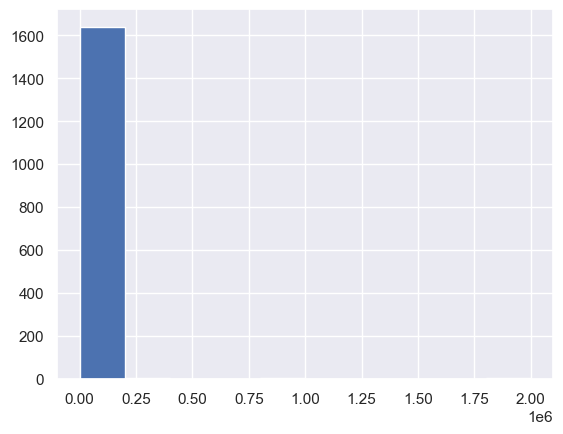

In [32]:
car_train_features["Kilometer"].hist()

<Axes: >

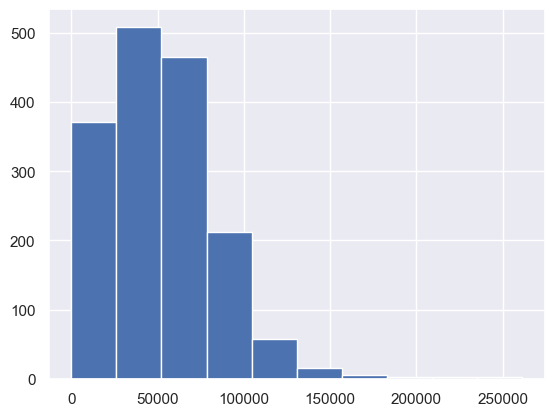

In [33]:
kilometer_mask = car_train_features["Kilometer"] <= 500000
car_train_features = car_train_features[kilometer_mask]
car_train_labels = car_train_labels[kilometer_mask]

car_train_features["Kilometer"].hist()

#### Handling Missing Data

Let's start by handling missing data. The Drivetrain attribute is missing from several rows. I will replace its missing values with a "Unspecified" value since I would like my model to predict prices for data with missing Drivetrain, as that makes up about 5% of the data. Furthermore, intuitively the missing drivetrain may give some information about the price of the car (at the very least, buyers may be less interested in a less detailed car ad, and this may drive the price down somewhat).

In [34]:
def ReplaceNaN(X, replacement):
    return X.apply(lambda x: replacement if pd.isna(x) else x)

car_train_features["Drivetrain"] = ReplaceNaN(car_train_features["Drivetrain"], "Unspecified")

In [35]:
car_train_features.info()

<class 'pandas.DataFrame'>
Index: 1645 entries, 1619 to 1863
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                1645 non-null   str    
 1   Model               1645 non-null   str    
 2   Year                1645 non-null   int64  
 3   Kilometer           1645 non-null   int64  
 4   Fuel Type           1645 non-null   str    
 5   Transmission        1645 non-null   str    
 6   Color               1645 non-null   str    
 7   Owner               1645 non-null   str    
 8   Seller Type         1645 non-null   str    
 9   Engine              1582 non-null   float64
 10  Drivetrain          1645 non-null   str    
 11  Length              1594 non-null   float64
 12  Width               1594 non-null   float64
 13  Seating Capacity    1594 non-null   float64
 14  Fuel Tank Capacity  1555 non-null   float64
dtypes: float64(5), int64(2), str(8)
memory usage: 205.6 KB


Only numerical features remain with null values. Since we have seen in the data analysis notebook that many of these features are collinear, a good idea to impute the missing data would be to derive it as a linear function of the other features. However, this can only be done if the same rows don't have multiple NaN values.

For example, we know that Length and Width are strongly linearly correlated.

In [36]:

def nanIndices(X, feature):
    return set(X[X[feature].isna()].index)

def symmetricDifference(A, B):
    return set(product((A - B), {0})).union(set(product((B - A), {1})))

In [37]:
diff = symmetricDifference(nanIndices(car_train_features, "Length"), nanIndices(car_train_features, "Width"))
diff

set()

Unfortunately, they are null on exactly the same rows!

We saw that Fuel Tank Capacity was also highly linearly correlated with both Length and Width, so let's check those values too.

In [38]:
diff = symmetricDifference(nanIndices(car_train_features, "Fuel Tank Capacity"), nanIndices(car_train_features, "Width"))
diff

{(6, 0),
 (93, 0),
 (127, 0),
 (134, 0),
 (180, 0),
 (200, 0),
 (237, 0),
 (334, 0),
 (338, 0),
 (481, 0),
 (510, 0),
 (639, 0),
 (715, 0),
 (774, 0),
 (868, 0),
 (872, 0),
 (909, 0),
 (1126, 0),
 (1146, 0),
 (1149, 0),
 (1177, 0),
 (1254, 0),
 (1269, 0),
 (1283, 0),
 (1294, 0),
 (1298, 0),
 (1403, 0),
 (1449, 0),
 (1583, 0),
 (1741, 0),
 (1865, 0),
 (1906, 0),
 (1944, 0),
 (1952, 0),
 (1979, 0),
 (2008, 0),
 (2017, 0),
 (2019, 0),
 (2058, 0)}

So for 39 values, we can estimate their Fuel Tank Capacity based on Width or Length (the 0 indicates that the value is Nan for the first feature but not for the second)! Here I will use a simple linear regression. 

#### Imputer for Fuel Tank Capacity

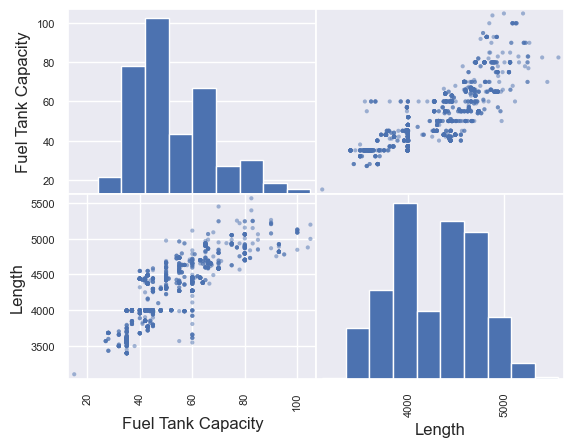

In [39]:

car_train_reduced = car_train_features[["Fuel Tank Capacity", "Length"]].copy().dropna()
scatter_matrix(car_train_reduced)
plt.show()

In [40]:
train_set, test_set = train_test_split(car_train_reduced, test_size=0.2)
X_train = train_set["Length"].to_numpy().reshape(-1,1)
y_train = train_set["Fuel Tank Capacity"].to_numpy()
lr= LinearRegression(fit_intercept=True)
capacity_predictor = lr.fit(X_train, y_train)
capacity_predictor

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
X_test = test_set["Length"].to_numpy().reshape(-1,1)
y_test = test_set["Fuel Tank Capacity"].to_numpy()

In [42]:
y_predicted = capacity_predictor.predict(X_test)

In [43]:
root_mean_squared_error(y_test, y_predicted)

8.759896344993436

To get a sense of whether this is a good predictor, let's compare its RMSE against that of the mean predictor, which is obtained by just taking the mean of Fuel Tank Capacity across the (training) data.

In [44]:
mean_predictor = np.ones((len(y_test), 1)) * y_train.mean()

In [45]:
root_mean_squared_error(y_test, mean_predictor)

15.56905632125437

We can see our linear regression does considerably better at predicting Fuel Tank Capacity than a simple mean predictor. This is useful because another common imputation strategy for missing values is to use the mean, and we have some evidence here that our Linear Regression provides a better estimate.

We can now use the imputator to fill-in the NaN values in the Fuel Tank Capacity column

In [46]:
def regressionImpute(X, target, feature, predictor):
    I = nanIndices(X, target)
    for i in I:
        if not pd.isna(X[feature][i]):
            X.loc[i, target] = predictor.predict(X[feature][i].reshape(1,-1))

In [47]:
car_train_features["Fuel Tank Capacity"].info()

<class 'pandas.Series'>
Index: 1645 entries, 1619 to 1863
Series name: Fuel Tank Capacity
Non-Null Count  Dtype  
--------------  -----  
1555 non-null   float64
dtypes: float64(1)
memory usage: 25.7 KB


In [48]:
regressionImpute(car_train_features, "Fuel Tank Capacity", "Length", capacity_predictor)
car_train_features["Fuel Tank Capacity"].info()

<class 'pandas.Series'>
Index: 1645 entries, 1619 to 1863
Series name: Fuel Tank Capacity
Non-Null Count  Dtype  
--------------  -----  
1594 non-null   float64
dtypes: float64(1)
memory usage: 90.2 KB


We managed to fill 39 of the 90 missing Fuel Tank Capacity values!

#### Imputer for Engine

We also know Engine and Fuel Tank Capacity are strongly linearly correlated, so let's see if we can use one to impute the other.

In [49]:
diff = symmetricDifference(nanIndices(car_train_features, "Fuel Tank Capacity"), nanIndices(car_train_features, "Engine"))
diff

{(127, 1),
 (338, 1),
 (409, 1),
 (449, 1),
 (639, 1),
 (909, 1),
 (1075, 1),
 (1173, 1),
 (1278, 1),
 (1526, 1),
 (1906, 1),
 (1980, 1)}

It looks like for 12 rows we will be able to use Fuel Tank Capacity to impute Engine.

In [50]:
car_train_reduced2 = car_train_features[["Fuel Tank Capacity", "Engine"]].copy().dropna()
train_set, test_set = train_test_split(car_train_reduced2, test_size=0.2)
X_train = train_set["Fuel Tank Capacity"].to_numpy().reshape(-1,1)
y_train = train_set["Engine"].to_numpy()
lr= LinearRegression(fit_intercept=True)
engine_predictor = lr.fit(X_train, y_train)
engine_predictor

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
X_test = test_set["Fuel Tank Capacity"].to_numpy().reshape(-1,1)
y_test = test_set["Engine"].to_numpy()

y_predicted = engine_predictor.predict(X_test)

root_mean_squared_error(y_test, y_predicted)

310.89971926554034

In [52]:
mean_predictor = np.ones((len(y_test), 1)) * y_train.mean()
root_mean_squared_error(y_test, mean_predictor)

579.3864025934785

Again this does significantly better than just using the (training) sample mean to impute the missing values!

In [53]:
car_train_features["Engine"].info()

<class 'pandas.Series'>
Index: 1645 entries, 1619 to 1863
Series name: Engine
Non-Null Count  Dtype  
--------------  -----  
1582 non-null   float64
dtypes: float64(1)
memory usage: 90.2 KB


In [54]:
regressionImpute(car_train_features, "Engine", "Fuel Tank Capacity", engine_predictor)
car_train_features["Engine"].info()

<class 'pandas.Series'>
Index: 1645 entries, 1619 to 1863
Series name: Engine
Non-Null Count  Dtype  
--------------  -----  
1594 non-null   float64
dtypes: float64(1)
memory usage: 90.2 KB


#### Dealing with the remaining NaN values

In [55]:
car_train_features.info()

<class 'pandas.DataFrame'>
Index: 1645 entries, 1619 to 1863
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                1645 non-null   str    
 1   Model               1645 non-null   str    
 2   Year                1645 non-null   int64  
 3   Kilometer           1645 non-null   int64  
 4   Fuel Type           1645 non-null   str    
 5   Transmission        1645 non-null   str    
 6   Color               1645 non-null   str    
 7   Owner               1645 non-null   str    
 8   Seller Type         1645 non-null   str    
 9   Engine              1594 non-null   float64
 10  Drivetrain          1645 non-null   str    
 11  Length              1594 non-null   float64
 12  Width               1594 non-null   float64
 13  Seating Capacity    1594 non-null   float64
 14  Fuel Tank Capacity  1594 non-null   float64
dtypes: float64(5), int64(2), str(8)
memory usage: 270.2 KB


We know that for Length, Width, Fuel Tank Capacity, and Engine, the null values overlap: so we only have 51 rows with NaN in any of those columns. Seating Capacity also has the same number of null values, but we should check whether they overlap too: if not, we could have up to 102 rows with NaN values!

In [56]:
diff = symmetricDifference(nanIndices(car_train_features, "Length"), nanIndices(car_train_features, "Seating Capacity"))
diff

set()

It looks like the NaN values overlap. This further shows that the pattern of missing values is somewhat structured.

In [57]:
car_train_features[car_train_features["Length"].isna()].head()

,Make,Model,Year,Kilometer,Fuel Type,Transmission,Color,Owner,Seller Type,Engine,Drivetrain,Length,Width,Seating Capacity,Fuel Tank Capacity
729,Jaguar,XF R 5.0 V8 Supercharged,2011,70662,Petrol,Automatic,Grey,Second,Individual,NaN,Unspecified,NaN,NaN,NaN,NaN
727,Jaguar,XF 3.0 V6 Premium Luxury,2015,62645,Diesel,Automatic,Bronze,First,Individual,NaN,Unspecified,NaN,NaN,NaN,NaN
1438,Audi,A4 2.0 TDI Sline,2012,56000,Diesel,Automatic,White,Second,Individual,NaN,Unspecified,NaN,NaN,NaN,NaN
1682,Maruti Suzuki,Ritz VXI BS-IV,2011,58888,Petrol,Manual,Maroon,Second,Individual,NaN,Unspecified,NaN,NaN,NaN,NaN
291,Maruti Suzuki,Ritz VXI BS-IV,2011,90000,Petrol,Manual,White,Second,Individual,NaN,Unspecified,NaN,NaN,NaN,NaN


NOTE: A natural idea would be to use the Make and Model fields to determine the numerical features, since all cars with same model and make should have the same Length, Width, etc. However, a quick look at the data shows that the Models which have  NaN numerical attributes above never appear with non-Null numerical attributes in the database. I.e. we cannot derive their Length, Width etc. from this database. However, we could fetch this data elsewhere, but I will avoid doing so here for simplicity.

Instead of merely dropping these rows, I will add a further feature "Incomplete", which will be 1 whenever the row is missing all the above features (the only ones that can be null at this point) and will be 0 otherwise. This is because:
- I expect most of the predictive power of the model to come from Make-Model-Kilometer feature group, so the model should be able to make OK predictions even for rows that are missing lots of details about the car in question.
- For the models who have all these feature Null, we **do not have any other rows**. Hence if we drop these rows, the model will know **nothing** about the price of these car models. It seems preferable to keep the rows, so that the model can at least learn something about these car models.    

In [58]:
car_train_features["Incomplete"] = np.zeros((len(car_train_features), 1))
for i in nanIndices(car_train_features, "Length"):
    car_train_features.loc[i, "Incomplete"] = 1

Then we can use a simple median imputer for filling in the NaN values in the attributes Length, Width, Tank Engine Capacity, Seating Capacity, and Engine.

In [59]:
median_imputer = SimpleImputer(strategy="median")

In [60]:
car_num = car_train_features.select_dtypes(include=[np.number])
car_num.info()

<class 'pandas.DataFrame'>
Index: 1645 entries, 1619 to 1863
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                1645 non-null   int64  
 1   Kilometer           1645 non-null   int64  
 2   Engine              1594 non-null   float64
 3   Length              1594 non-null   float64
 4   Width               1594 non-null   float64
 5   Seating Capacity    1594 non-null   float64
 6   Fuel Tank Capacity  1594 non-null   float64
 7   Incomplete          1645 non-null   float64
dtypes: float64(6), int64(2)
memory usage: 180.2 KB


In [61]:
median_imputer.fit(car_num)

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [62]:
median_imputer.statistics_

array([2.017e+03, 5.000e+04, 1.497e+03, 4.370e+03, 1.770e+03, 5.000e+00,
       5.000e+01, 0.000e+00])

In [63]:
car_num.median().values

array([2.017e+03, 5.000e+04, 1.497e+03, 4.370e+03, 1.770e+03, 5.000e+00,
       5.000e+01, 0.000e+00])

In [64]:
car_num_filled = pd.DataFrame(median_imputer.transform(car_num), columns = car_num.columns, index=car_num.index)
car_num_filled.info()

<class 'pandas.DataFrame'>
Index: 1645 entries, 1619 to 1863
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                1645 non-null   float64
 1   Kilometer           1645 non-null   float64
 2   Engine              1645 non-null   float64
 3   Length              1645 non-null   float64
 4   Width               1645 non-null   float64
 5   Seating Capacity    1645 non-null   float64
 6   Fuel Tank Capacity  1645 non-null   float64
 7   Incomplete          1645 non-null   float64
dtypes: float64(8)
memory usage: 180.2 KB


In [65]:
for feature in car_num_filled.columns:
    car_train_features[feature] = car_num_filled[feature]

car_train_features.info()

<class 'pandas.DataFrame'>
Index: 1645 entries, 1619 to 1863
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                1645 non-null   str    
 1   Model               1645 non-null   str    
 2   Year                1645 non-null   float64
 3   Kilometer           1645 non-null   float64
 4   Fuel Type           1645 non-null   str    
 5   Transmission        1645 non-null   str    
 6   Color               1645 non-null   str    
 7   Owner               1645 non-null   str    
 8   Seller Type         1645 non-null   str    
 9   Engine              1645 non-null   float64
 10  Drivetrain          1645 non-null   str    
 11  Length              1645 non-null   float64
 12  Width               1645 non-null   float64
 13  Seating Capacity    1645 non-null   float64
 14  Fuel Tank Capacity  1645 non-null   float64
 15  Incomplete          1645 non-null   float64
dtypes: float64(8), str(

This successfully imputes all remaining NaN values.

### Handling Categorical Features

In [66]:
car_cat = car_train_features.select_dtypes(include=object)
car_cat.info()

<class 'pandas.DataFrame'>
Index: 1645 entries, 1619 to 1863
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Make          1645 non-null   str  
 1   Model         1645 non-null   str  
 2   Fuel Type     1645 non-null   str  
 3   Transmission  1645 non-null   str  
 4   Color         1645 non-null   str  
 5   Owner         1645 non-null   str  
 6   Seller Type   1645 non-null   str  
 7   Drivetrain    1645 non-null   str  
dtypes: str(8)
memory usage: 180.2 KB


C:\Users\molin\AppData\Local\Temp\ipykernel_3564\1446050651.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  car_cat = car_train_features.select_dtypes(include=object)


#### Model: Feature Encoding

In [67]:
car_train_features["Model"].value_counts()

Model
X1 sDrive20d xLine                 13
City V                             12
Fortuner 2.8 4x2 AT [2016-2020]    11
Swift VXi                          11
Swift DZire VXI                     9
                                   ..
Innova GX 2.4 AT 7 STR              1
A7 Sportback 3.0 TDI quattro        1
Tiguan AllSpace 2.0 TSI             1
Scorpio S9 2WD 7 STR                1
Baleno Delta 1.2 AT                 1
Name: count, Length: 908, dtype: int64

There are too many models to perform one-hot encoding. Therefore, as discussed above, I will represent each model with the average price for that model (across the training data). To perform this transformation, we first need to retrieve the price data.

In [68]:
car_tmp = pd.DataFrame()
car_tmp["Model"] = car_train_features["Model"]
car_tmp["Price"] = car_train_labels
car_tmp.head()

,Model,Price
1619,Scorpio S2,650000
1172,Verna Fluidic 1.6 CRDi SX,545000
312,Fortuner 3.0 4x2 AT,1525000
75,Jazz VX Petrol,570000
522,i10 Sportz 1.2,270000


In [69]:
car_tmp_grouped = car_tmp.groupby("Model").mean()
car_tmp_grouped.head()

,Price
Model,
2 Series Gran Coupe 220d M Sport [2020-2021],4.200000e+06
3-Series 320d,8.000000e+05
3-Series 320d Highline Sedan,1.200000e+06
3-Series 320d Luxury Edition,4.550000e+06
3-Series 320d Luxury Line,2.358333e+06


In [70]:
array = car_tmp_grouped.index.to_numpy() 
car_train_features["Model"] = car_train_features["Model"].apply(lambda x: car_tmp_grouped.loc[x, "Price"] if x in array else x)

In [71]:
car_train_features.info()

<class 'pandas.DataFrame'>
Index: 1645 entries, 1619 to 1863
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                1645 non-null   str    
 1   Model               1645 non-null   float64
 2   Year                1645 non-null   float64
 3   Kilometer           1645 non-null   float64
 4   Fuel Type           1645 non-null   str    
 5   Transmission        1645 non-null   str    
 6   Color               1645 non-null   str    
 7   Owner               1645 non-null   str    
 8   Seller Type         1645 non-null   str    
 9   Engine              1645 non-null   float64
 10  Drivetrain          1645 non-null   str    
 11  Length              1645 non-null   float64
 12  Width               1645 non-null   float64
 13  Seating Capacity    1645 non-null   float64
 14  Fuel Tank Capacity  1645 non-null   float64
 15  Incomplete          1645 non-null   float64
dtypes: float64(9), str(

Now Model can be treated as a simple numerical feature.

#### One-hot encodings

For all the other categorical variables I will use one-hot encoding.

In [72]:
car_cat = car_cat.drop("Model", axis=1)
one_hot_encoder = OneHotEncoder(sparse_output=False)
car_cat_1hot = one_hot_encoder.fit_transform(car_cat)
car_cat_1hot

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]], shape=(1645, 61))

### Feature Scaling

Based on exploratory data analysis, I will apply a StandardScaler to all numerical features. For the labels, I will first take the logarithm and then apply a StandardScaler, as a way to make the heavy-tailed, heavy-skewed distribution of prices closer to a normal.

In [73]:
# Get list of numerical features to be normalised (exclude Incomplete flag)
car_num = car_train_features.select_dtypes(include=[np.number]).drop("Incomplete", axis=1)
car_num.info()

<class 'pandas.DataFrame'>
Index: 1645 entries, 1619 to 1863
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Model               1645 non-null   float64
 1   Year                1645 non-null   float64
 2   Kilometer           1645 non-null   float64
 3   Engine              1645 non-null   float64
 4   Length              1645 non-null   float64
 5   Width               1645 non-null   float64
 6   Seating Capacity    1645 non-null   float64
 7   Fuel Tank Capacity  1645 non-null   float64
dtypes: float64(8)
memory usage: 180.2 KB


In [74]:
standard_scaler = StandardScaler()

car_num_scaled = standard_scaler.fit_transform(car_num)

#### Transforming the labels

In [75]:
car_train_labels

1619     650000
1172     545000
312     1525000
75       570000
522      270000
         ...   
150     1575000
826      721000
407      570000
578      625000
1863    1180000
Name: Price, Length: 1645, dtype: int64

In [76]:
def log_transform(X):
    return X.apply(lambda x: np.log(x))

labels_scaled = standard_scaler.fit_transform(pd.DataFrame(log_transform(car_train_labels)))

### Building Transformation Pipelines

Here I put together the various transformations in the previous subsections to build a pipeline that Cleans, Transforms, and Scales the data for our machine learning model.

First I need to define a custom transformer that imputes the values of a feature by using linear regression on another. (This is quite basic, a better approach would be to try and use each of the other features to impute the missing ones, along the lines of the IterativeImputer provided by scikit learn

#### Defining custom transformers for imputing Fuel Tank Capacity and Engine

In [77]:
class linear_imputer(BaseEstimator, TransformerMixin):
    def __init__(self, feature_name, target_name):
        self.feature_name = feature_name
        self.target_name = target_name

    # Keep feature names unchanged
    def get_feature_names_out(self, input_features=None):
        return input_features

    # train linear predictor on rows where neither feature nor target are null
    def fit(self, X, y=None):
        reducedX = X[[self.feature_name, self.target_name]].dropna()
        self.linearReg_ = LinearRegression(fit_intercept=True)
        self.linearReg_.fit(reducedX[self.feature_name].to_numpy().reshape(-1,1), 
                            reducedX[self.target_name].to_numpy())
        return self

    def transform(self, X):
        ## on rows where target is null and feature is not null, predict target from feature
        mask = X[self.target_name].isna() & ~ X[self.feature_name].isna()
        X = X.copy() # safety
        if mask.sum() > 0:
            X.loc[mask, self.target_name] = self.linearReg_.predict(X[mask][self.feature_name].to_numpy().reshape(-1,1))
        return X

In [78]:
X = car_train_set.copy()
X["Fuel Tank Capacity"].info()

<class 'pandas.Series'>
Index: 1647 entries, 1619 to 1863
Series name: Fuel Tank Capacity
Non-Null Count  Dtype  
--------------  -----  
1557 non-null   float64
dtypes: float64(1)
memory usage: 25.7 KB


In [79]:
linput = linear_imputer(feature_name="Length", target_name="Fuel Tank Capacity")
linput

,feature_name,'Length'
,target_name,'Fuel Tank Capacity'


In [80]:
linput.fit(X)

,feature_name,'Length'
,target_name,'Fuel Tank Capacity'


In [81]:
X_inputed = linput.transform(X)

In [82]:
X_inputed["Fuel Tank Capacity"].info()

<class 'pandas.Series'>
Index: 1647 entries, 1619 to 1863
Series name: Fuel Tank Capacity
Non-Null Count  Dtype  
--------------  -----  
1596 non-null   float64
dtypes: float64(1)
memory usage: 25.7 KB


#### Building the preprocessing pipeline for features

In [83]:
def extractNumber(x):
    if type(x) is str:
        return int((re.search(r"\d+", x).group()))
    else:
        return x

def extractNumberTransform(X):
    return X.map(extractNumber)

extract_number_transformer = FunctionTransformer(extractNumberTransform, feature_names_out="one-to-one")

In [84]:
engine_pipeline = make_pipeline(
    FunctionTransformer(extractNumberTransform, feature_names_out="one-to-one"),
    linear_imputer("Length", "Engine"),
    SimpleImputer(strategy="mean"),
    StandardScaler()
)

In [85]:
extract_engine_num = ColumnTransformer([
    ("extract_number", FunctionTransformer(extractNumberTransform, feature_names_out="one-to-one"), ["Engine"])
], remainder='passthrough', verbose_feature_names_out=False) 

extract_engine_num.set_output(transform="pandas")

,transformers,"[('extract_number', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,func,<function ext...00151A27A7600>
,inverse_func,None
,validate,False


In [86]:
## Pipeline that applies target encoding to Model and then standardizes it
car_model_pipeline = Pipeline([
    ("target_encoder", TargetEncoder(target_type="continuous", random_state=42)),
    ("standard_scaler", StandardScaler())
])

In [87]:
## Pipeline to impute NaN values with mean and scale
## Applied to every numerical feature
num_pipeline = Pipeline([
    ("simple_imputer_mean", SimpleImputer(strategy="mean")),
    ("standard_scaler", StandardScaler())
])

In [88]:
preprocessing_pipeline = Pipeline([
    ("extract_engine_num", extract_engine_num),
    ("linear_imputer_engine", linear_imputer("Length", "Engine")),
    ("linear_imputer_fuel_tank_capacity", linear_imputer("Length", "Fuel Tank Capacity")),
    ("column_processing", ColumnTransformer([ 
        ("num_pipeline", num_pipeline, make_column_selector(dtype_include=np.number)),
        ("car_model_pipeline", car_model_pipeline, ["Model"]),
        ("cat_encoding", OneHotEncoder(sparse_output=False), ["Make", "Fuel Type", "Transmission", "Color", "Owner", "Seller Type", "Drivetrain"]) # exclude Model bc handled above
    ], verbose_feature_names_out=False))
])

preprocessing_pipeline

,steps,"[('extract_engine_num', ...), ('linear_imputer_engine', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('extract_number', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [89]:
X = car_train_set.copy().drop("Price", axis=1)
X.info()

<class 'pandas.DataFrame'>
Index: 1647 entries, 1619 to 1863
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                1647 non-null   str    
 1   Model               1647 non-null   str    
 2   Year                1647 non-null   int64  
 3   Kilometer           1647 non-null   int64  
 4   Fuel Type           1647 non-null   str    
 5   Transmission        1647 non-null   str    
 6   Location            1647 non-null   str    
 7   Color               1647 non-null   str    
 8   Owner               1647 non-null   str    
 9   Seller Type         1647 non-null   str    
 10  Engine              1584 non-null   str    
 11  Max Power           1584 non-null   str    
 12  Max Torque          1584 non-null   str    
 13  Drivetrain          1533 non-null   str    
 14  Length              1596 non-null   float64
 15  Width               1596 non-null   float64
 16  Height             

In [90]:
Y = car_train_set.copy()["Price"]
Y.info()

<class 'pandas.Series'>
Index: 1647 entries, 1619 to 1863
Series name: Price
Non-Null Count  Dtype
--------------  -----
1647 non-null   int64
dtypes: int64(1)
memory usage: 25.7 KB


In [91]:
X_preprocessed = preprocessing_pipeline.fit_transform(X, Y.to_numpy())

In [92]:
feature_names = preprocessing_pipeline.get_feature_names_out()
feature_names

array(['Engine', 'Year', 'Kilometer', 'Length', 'Width', 'Height',
       'Seating Capacity', 'Fuel Tank Capacity', 'Model', 'Make_Audi',
       'Make_BMW', 'Make_Chevrolet', 'Make_Datsun', 'Make_Ford',
       'Make_Honda', 'Make_Hyundai', 'Make_Jaguar', 'Make_Jeep',
       'Make_Kia', 'Make_Land Rover', 'Make_Lexus', 'Make_MG',
       'Make_MINI', 'Make_Mahindra', 'Make_Maruti Suzuki',
       'Make_Mercedes-Benz', 'Make_Nissan', 'Make_Other',
       'Make_Other Luxury', 'Make_Porsche', 'Make_Renault', 'Make_Skoda',
       'Make_Tata', 'Make_Toyota', 'Make_Volkswagen', 'Make_Volvo',
       'Fuel Type_CNG', 'Fuel Type_Diesel',
       'Fuel Type_Electric or Hybrid', 'Fuel Type_Other',
       'Fuel Type_Petrol', 'Transmission_Automatic',
       'Transmission_Manual', 'Color_Beige', 'Color_Black', 'Color_Blue',
       'Color_Bronze', 'Color_Brown', 'Color_Gold', 'Color_Green',
       'Color_Grey', 'Color_Maroon', 'Color_Orange', 'Color_Other',
       'Color_Others', 'Color_Red', 'Color_Sil

In [93]:
X_preprocessed_df = pd.DataFrame(
    X_preprocessed,
    columns=feature_names
)

In [94]:
X_preprocessed_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1647 entries, 0 to 1646
Data columns (total 70 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Engine                               1647 non-null   float64
 1   Year                                 1647 non-null   float64
 2   Kilometer                            1647 non-null   float64
 3   Length                               1647 non-null   float64
 4   Width                                1647 non-null   float64
 5   Height                               1647 non-null   float64
 6   Seating Capacity                     1647 non-null   float64
 7   Fuel Tank Capacity                   1647 non-null   float64
 8   Model                                1647 non-null   float64
 9   Make_Audi                            1647 non-null   float64
 10  Make_BMW                             1647 non-null   float64
 11  Make_Chevrolet                       1647

#### Building transform for target

NOTE: Currently I'm not using this, would be interesting to see if it improves performance.

In [95]:
log_transformer = FunctionTransformer(np.log, feature_names_out="one-to-one")

target_pipeline = Pipeline([
    ("log_transformer", log_transformer),
    ("standard scaler", StandardScaler())
])

In [96]:
Y = car_train_set.copy()["Price"]
Y.head()

1619     650000
1172     545000
312     1525000
75       570000
522      270000
Name: Price, dtype: int64

In [97]:
Y_preprocessed = target_pipeline.fit_transform(Y.to_frame())
Y_preprocessed

array([[-0.43517606],
       [-0.61364733],
       [ 0.4286597 ],
       ...,
       [-0.56821516],
       [-0.47490537],
       [ 0.16885381]], shape=(1647, 1))

In [98]:
Y_preprocessed_df = pd.DataFrame(
    Y_preprocessed,
    columns=target_pipeline.get_feature_names_out()
)

Y_preprocessed_df.head()

,Price
0,-0.435176
1,-0.613647
2,0.428660
3,-0.568215
4,-1.325119


## Selecting and Training models

#### Copying the data

In [99]:
X = car_train_set.drop("Price", axis=1)
Y = car_train_set["Price"].copy()
X.info()

<class 'pandas.DataFrame'>
Index: 1647 entries, 1619 to 1863
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                1647 non-null   str    
 1   Model               1647 non-null   str    
 2   Year                1647 non-null   int64  
 3   Kilometer           1647 non-null   int64  
 4   Fuel Type           1647 non-null   str    
 5   Transmission        1647 non-null   str    
 6   Location            1647 non-null   str    
 7   Color               1647 non-null   str    
 8   Owner               1647 non-null   str    
 9   Seller Type         1647 non-null   str    
 10  Engine              1584 non-null   str    
 11  Max Power           1584 non-null   str    
 12  Max Torque          1584 non-null   str    
 13  Drivetrain          1533 non-null   str    
 14  Length              1596 non-null   float64
 15  Width               1596 non-null   float64
 16  Height             

In [100]:
Y.info()

<class 'pandas.Series'>
Index: 1647 entries, 1619 to 1863
Series name: Price
Non-Null Count  Dtype
--------------  -----
1647 non-null   int64
dtypes: int64(1)
memory usage: 25.7 KB


#### Linear Regression

In [101]:
lin_reg = make_pipeline(preprocessing_pipeline, LinearRegression(fit_intercept=True))

lin_reg.fit(X, Y.to_numpy())

,steps,"[('pipeline', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('extract_engine_num', ...), ('linear_imputer_engine', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('extract_number', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3


We can use cross-validation to get an idea of how linear regression performs

In [102]:
## Cross-validation
lin_reg_cv = -cross_val_score(lin_reg, X, Y.to_numpy(), scoring = "neg_root_mean_squared_error", cv=10)
lin_reg_cv.mean()

np.float64(1277435.7329901434)

In [103]:
np.set_printoptions(suppress=True)
pd.options.display.float_format = '{:.6f}'.format

pd.Series(lin_reg_cv).describe()

count        10.000000
mean    1277435.732990
std      402292.127318
min      854972.141489
25%      954873.986395
50%     1134278.700231
75%     1568655.694532
max     2066704.163625
dtype: float64

In [104]:
Y.mean(), np.sqrt(Y.var())

(np.float64(1723303.5373406194), np.float64(2461002.09041567))

In [105]:
def mean_predictor(X):
    return np.ones((len(X), 1)) * Y.mean()

In [106]:
root_mean_squared_error(Y, mean_predictor(X))

2460254.8603725107

Our linear predictor is already doing much better than the mean predictor, even though the results are still not great.

Presumably, the linear regression is too simple to be overfitting the training data. But let's just do a safety check

In [107]:
lin_reg.fit(X,Y)
root_mean_squared_error(Y, lin_reg.predict(X))

1020011.7070850558

It's quite a bit better tan the mean across the cross-validation folds. It may be that some features (e.g. Model) are getting excessively high weight, causing overfitting. We can get a sense of this by looking at the weigths for each category

In [108]:
pd.Series(lin_reg.named_steps["linearregression"].coef_).describe()

count         70.000000
mean       24196.022605
std      2085164.878692
min     -1864407.625503
25%      -511372.936135
50%       -68860.175220
75%       121929.030816
max     15537343.601661
dtype: float64

We can see that coefficient magnitude explodes for some features, as expected. Thus Ridge regression or other normalisations may provide some benefit here.

#### Tree Regressor

In [109]:
tree_reg = make_pipeline(preprocessing_pipeline, DecisionTreeRegressor(random_state=42))

In [110]:
tree_reg_cv = -cross_val_score(tree_reg, X, Y.to_numpy(), scoring = "neg_root_mean_squared_error", cv=10)
pd.Series(tree_reg_cv).describe()

count        10.000000
mean    1255718.077789
std      576357.850138
min      663525.460675
25%      747800.916089
50%     1184141.700915
75%     1465841.135628
max     2298718.087507
dtype: float64

No better than the linear regression!

In [111]:
tree_reg.fit(X, Y)
root_mean_squared_error(Y, tree_reg.predict(X))

314924.86178186967

This is far, far better than the cross-validation mean, and indeed better than the model's score on any of the cross validation folds (although still not great) suggesting that there is significant overfitting.

#### Random Forest Regressor

In [112]:
forest_reg = make_pipeline(preprocessing_pipeline, RandomForestRegressor(random_state=42))

In [113]:
forest_reg_cv = -cross_val_score(forest_reg, X, Y.to_numpy(), scoring = "neg_root_mean_squared_error", cv=10)

pd.Series(forest_reg_cv).describe()

count        10.000000
mean     910345.117228
std      458310.253953
min      405146.185336
25%      590919.029369
50%      713484.765431
75%     1205233.231418
max     1893222.222940
dtype: float64

This is significantly better than the previous two models! However, it is still quite poor overall.

Let's check for overfitting by measuring the error on training set

In [114]:
forest_reg_cv

array([ 597156.72087391,  584404.15982128, 1250885.00830516,
       1893222.22294009, 1288549.64451237,  710816.158803  ,
       1068277.90075775,  716153.37205858,  405146.18533606,
        588839.79886758])

In [115]:
forest_reg.fit(X, Y)

,steps,"[('pipeline', ...), ('randomforestregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('extract_engine_num', ...), ('linear_imputer_engine', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('extract_number', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3


In [116]:
root_mean_squared_error(Y, forest_reg.predict(X))

437261.21799853444

This is still about 1/2 of the mean cross validation score: thus suggesting that the model is still overfitting the data quite severely.

#### Ridge Regression

In [117]:
ridge_reg = make_pipeline(preprocessing_pipeline, Ridge())

In [119]:
ridge_reg_cv = -cross_val_score(ridge_reg, X, Y.to_numpy(), scoring = "neg_root_mean_squared_error", cv=10)

pd.Series(ridge_reg_cv).describe()

count        10.000000
mean    1281592.368600
std      392058.459298
min      854423.533713
25%      998350.912065
50%     1153209.686086
75%     1476442.296150
max     2048933.287096
dtype: float64

Performance is similar to the simple linear model

In [120]:
ridge_reg.fit(X,Y)
root_mean_squared_error(Y, ridge_reg.predict(X))

992159.9970009523

This reduces the overfitting a little, but performance is pretty poor including on the training set. Indeed, it performs worse than Random Forest, even on the training set! But does improve considerably over simple Linear Regression.

#### Support Vector Machines

In [121]:
svm_reg = make_pipeline(preprocessing_pipeline, svm.SVR())

svm_reg_cv = -cross_val_score(svm_reg, X, Y.to_numpy(), scoring = "neg_root_mean_squared_error", cv=10)
pd.Series(svm_reg_cv).describe()

count        10.000000
mean    2578316.692214
std      472000.877138
min     1794923.339849
25%     2380482.679875
50%     2528497.691153
75%     2690393.525517
max     3345071.400464
dtype: float64

Performance is extremely bad. Let's see if this is due to overfitting.

In [122]:
svm_reg.fit(X,Y)
root_mean_squared_error(Y, svm_reg.predict(X))

2619030.1026313817

The problem here does not seem to be overfitting. In fact, it may be underfitting, as performance is even worse on the training set than across the cross-validation folds. 

In [123]:
svm_poly_reg = make_pipeline(preprocessing_pipeline, svm.SVR(kernel="poly", C=10, gamma="auto", degree=3, epsilon=0.5, coef0=1))
svm_poly_reg_cv = -cross_val_score(svm_poly_reg, X, Y.to_numpy(), scoring = "neg_root_mean_squared_error", cv=10)
pd.Series(svm_poly_reg_cv).describe()

count        10.000000
mean    2576641.923325
std      472166.381578
min     1793422.171048
25%     2378399.342055
50%     2526910.199429
75%     2688479.318477
max     3344204.832022
dtype: float64

In [124]:
svm_poly_reg.fit(X,Y)
root_mean_squared_error(Y, svm_poly_reg.predict(X))

2616458.7812432274

#### Polynomial Regression

In [125]:
preprocessing_pipeline.set_output(transform="pandas")
poly_pipeline = Pipeline([
    ("preprocessing", preprocessing_pipeline),
    ("num_poly", ColumnTransformer([
        ("poly", PolynomialFeatures(degree=2, include_bias=True), ["Engine", "Model", "Year", "Length", "Width", "Fuel Tank Capacity", "Kilometer", "Seating Capacity"]),
    ], remainder="passthrough", verbose_feature_names_out=False))
])

In [126]:
poly_reg = make_pipeline(poly_pipeline, LinearRegression())
poly_reg_cv = -cross_val_score(poly_reg, X, Y.to_numpy(), scoring = "neg_root_mean_squared_error", cv=10)
pd.Series(poly_reg_cv).describe()

count        10.000000
mean    1200278.419113
std      548072.965868
min      586913.443868
25%      716064.679283
50%     1150425.280490
75%     1591846.719622
max     2221664.300690
dtype: float64

This is definitely an improvement over the simple linear model

In [127]:
poly_reg.fit(X,Y)
root_mean_squared_error(Y, poly_reg.predict(X))

1322217.0331802247

Not much sign of overfit here.

Let's try to regularize the model

In [128]:
poly_ridge_reg =  make_pipeline(poly_pipeline, Ridge(alpha=1000))

poly_ridge_reg_cv = -cross_val_score(poly_ridge_reg, X, Y.to_numpy(), scoring = "neg_root_mean_squared_error", cv=10)
pd.Series(poly_ridge_reg_cv).describe()

count        10.000000
mean    1241232.097814
std      356530.232725
min      836379.675839
25%      953350.101885
50%     1163003.446668
75%     1449974.421291
max     1904810.177324
dtype: float64

In [129]:
poly_ridge_reg.fit(X,Y)
root_mean_squared_error(Y, poly_ridge_reg.predict(X))

991560.8027107102

The regularization seems to introduce further error!

In [130]:
poly_lasso_reg = make_pipeline(poly_pipeline, Lasso(alpha=1000))

In [131]:
poly_lasso_reg_cv = -cross_val_score(poly_lasso_reg, X, Y.to_numpy(), scoring = "neg_root_mean_squared_error", cv=10)
pd.Series(poly_lasso_reg_cv).describe()

count        10.000000
mean    1174598.456794
std      523132.628825
min      587379.339661
25%      719622.797739
50%     1146765.325175
75%     1490485.053929
max     2203573.786492
dtype: float64

In [132]:
poly_lasso_reg.fit(X,Y)
root_mean_squared_error(Y, poly_lasso_reg.predict(X))

1346937.399897798

Lasso shows some small improvements in CV score

The best-performing models among the candidates above seem to be **Random Forest** and **Polynomial Linear Regression** (possibly with Lasso regularization).

## Fine-Tuning 

### Searching the Hyperparameter space

#### Random Forest Regressor

In [133]:
forest_reg = make_pipeline(preprocessing_pipeline, RandomForestRegressor(random_state=42))
forest_reg

,steps,"[('pipeline', ...), ('randomforestregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('extract_engine_num', ...), ('linear_imputer_engine', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('extract_number', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3


I will use Randomized Search to explore the hyperparameter space in order to fine-tune the model. Since it looked like the RandomForest regressor was still overfitting the training data, one parameter to explore is **ccp_alpha**, which regulates the pruning of trees to reduce their complexity. Another natural choice for a parameter to explore is the **max_features** parameter of the RandomForest

In [134]:
parameter_dist = {
    "randomforestregressor__max_features": randint(low=1, high=20),
    "randomforestregressor__ccp_alpha": randint(low=0, high=100)}

random_search = RandomizedSearchCV(forest_reg, param_distributions= parameter_dist, n_iter=80, cv=3, scoring='neg_root_mean_squared_error', random_state=42)

In [135]:
random_search.fit(X, Y)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'randomforestregressor__ccp_alpha': <scipy.stats....00151A2CA0190>, 'randomforestregressor__max_features': <scipy.stats....00151A2893620>}"
,n_iter,80
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [136]:
random_search.best_params_

{'randomforestregressor__ccp_alpha': 3,
 'randomforestregressor__max_features': 14}

In [137]:
cv_res = pd.DataFrame(random_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_randomforestregressor__ccp_alpha,param_randomforestregressor__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
55,0.596338,0.013603,0.054911,0.001059,46,14,"{'randomforestregressor__ccp_alpha': 46, 'rand...",-817928.435164,-1437270.275559,-647717.399116,-967638.703280,339272.073179,1
57,0.589120,0.008094,0.051802,0.001242,4,14,"{'randomforestregressor__ccp_alpha': 4, 'rando...",-817928.435164,-1437270.275559,-647717.399116,-967638.703280,339272.073179,1
19,0.526922,0.049232,0.044032,0.005755,3,14,"{'randomforestregressor__ccp_alpha': 3, 'rando...",-817928.435164,-1437270.275559,-647717.399116,-967638.703280,339272.073179,1
14,0.683959,0.008234,0.054642,0.000351,61,19,"{'randomforestregressor__ccp_alpha': 61, 'rand...",-856000.428294,-1418408.202873,-632696.137454,-969034.922874,330573.703491,4
61,0.664751,0.008841,0.052952,0.001255,76,19,"{'randomforestregressor__ccp_alpha': 76, 'rand...",-856000.428294,-1418408.202873,-632696.137454,-969034.922874,330573.703491,4


It looks like the score changes by very little as we change these parameters. In particular, the value of ccp_alpha seems to have no impact on the score. Because of this, let's focus on the different values of max_features instead.

In [138]:
parameter_dist_max_features = {
    "randomforestregressor__max_features": randint(low=1, high=80)}

random_search_single_var = RandomizedSearchCV(forest_reg, param_distributions = parameter_dist_max_features, n_iter=50, cv=3, scoring='neg_root_mean_squared_error', random_state=42)

In [139]:
random_search_single_var.fit(X, Y)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,{'randomforestregressor__max_features': <scipy.stats....001519C8FBC50>}
,n_iter,50
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [140]:
random_search_single_var.best_params_

{'randomforestregressor__max_features': 44}

In [141]:
cv_res = pd.DataFrame(random_search_single_var.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_randomforestregressor__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
49,1.027867,0.010285,0.053262,0.001957,44,{'randomforestregressor__max_features': 44},-820633.638479,-1404683.323683,-614143.317785,-946486.759982,334781.153766,1
7,0.651557,0.053287,0.045480,0.005251,24,{'randomforestregressor__max_features': 24},-825266.446330,-1402686.498011,-654455.994543,-960802.979628,320145.628815,2
29,0.891269,0.005007,0.045000,0.002175,47,{'randomforestregressor__max_features': 47},-837780.891481,-1398473.725746,-647766.990993,-961340.536073,318685.204897,3
39,0.875741,0.046498,0.055595,0.006756,39,{'randomforestregressor__max_features': 39},-853931.999517,-1405632.338826,-626080.412211,-961881.583518,327276.779996,4
18,0.859566,0.013197,0.052200,0.000765,33,{'randomforestregressor__max_features': 33},-861665.361655,-1421506.641397,-605184.560500,-962785.521184,340846.397406,5


Still very minimal improvements, so perhaps there is not much to be gained from just fine-tuning this model.

#### Fine-Tuning Polynomial Regression

In [142]:
poly_reg = make_pipeline(poly_pipeline, LinearRegression())

poly_reg

,steps,"[('pipeline', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('preprocessing', ...), ('num_poly', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('extract_engine_num', ...), ('linear_imputer_engine', ...), ...]"
,transform_input,None
,memory,None


The ovious parameter to fine-tune is the **degree** of PolynomialFeatures. Although we have seen that performance worsens as we move from degree=2 to degree=3, so there seems not to be much point in doing this. A second thing to check is whether we fit intercept and/or include bias.

In [143]:
parameter_grid = [
    {
        "pipeline__num_poly__poly__include_bias":[True, False],
        "linearregression__fit_intercept":[True, False]
    }
]

In [144]:
grid_search = GridSearchCV(poly_reg, param_grid=parameter_grid, cv=5, scoring="neg_root_mean_squared_error")

grid_search.fit(X, Y)

,estimator,Pipeline(step...egression())])
,param_grid,"[{'linearregression__fit_intercept': [True, False], 'pipeline__num_poly__poly__include_bias': [True, False]}]"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,steps,"[('preprocessing', ...), ('num_poly', ...)]"


In [145]:
grid_search.best_params_

{'linearregression__fit_intercept': False,
 'pipeline__num_poly__poly__include_bias': False}

In [146]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_linearregression__fit_intercept,param_pipeline__num_poly__poly__include_bias,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
3,0.344964,0.082827,0.034382,0.001715,False,False,"{'linearregression__fit_intercept': False, 'pi...",-2082529.493167,-1218905.486993,-1089004.107099,-1292632.310554,-658676.683520,-1268349.616267,462555.756573,1
1,0.292729,0.116037,0.032866,0.003085,True,False,"{'linearregression__fit_intercept': True, 'pip...",-2082529.493168,-1218905.486993,-1089004.107099,-1292632.310554,-658676.683520,-1268349.616267,462555.756573,2
2,0.452348,0.093512,0.034970,0.005540,False,True,"{'linearregression__fit_intercept': False, 'pi...",-2082529.493168,-1218905.486993,-1089004.107099,-1292632.310554,-658676.683520,-1268349.616267,462555.756573,3
0,0.265725,0.130852,0.032321,0.003359,True,True,"{'linearregression__fit_intercept': True, 'pip...",-2082529.493168,-1218905.486993,-1089004.107099,-1292632.310554,-658676.683520,-1268349.616267,462555.756573,4


It looks like the mean test score is not at all affected by this choice!

#### Fine-tuning polynomial Lasso regression

Lasso effectively lets us ignore some categories that make little contribution to our prediction, thus reducing noise. Let's use random search to find the best hyperparameters for Lasso.

In [147]:
poly_lasso_reg = make_pipeline(poly_pipeline, Lasso())

In [148]:
parameter_grid = [
    {
        "lasso__alpha": randint(low=7000, high=8000)
    }
]

In [149]:
random_search_lasso = RandomizedSearchCV(poly_lasso_reg, param_distributions = parameter_grid, n_iter=100, cv=3, scoring='neg_root_mean_squared_error', random_state=42)
random_search_lasso.fit(X,Y)

,estimator,"Pipeline(step...o', Lasso())])"
,param_distributions,[{'lasso__alpha': <scipy.stats....00151A2A92190>}]
,n_iter,100
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [150]:
random_search_lasso.best_params_

{'lasso__alpha': 7510}

In [151]:
cv_res = pd.DataFrame(random_search_lasso.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_lasso__alpha,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
41,0.091731,0.001130,0.039988,0.003884,7510,{'lasso__alpha': 7510},-1602930.154773,-1298268.158947,-828281.895580,-1243160.069767,318640.505364,1
80,0.088772,0.003530,0.038567,0.000945,7508,{'lasso__alpha': 7508},-1602940.536713,-1298229.805451,-828314.200392,-1243161.514185,318628.182220,2
56,0.086898,0.005539,0.041454,0.002205,7504,{'lasso__alpha': 7504},-1602955.771021,-1298153.108603,-828378.868625,-1243162.582750,318601.436366,3
38,0.086694,0.001756,0.038588,0.002292,7560,{'lasso__alpha': 7560},-1602780.051224,-1299227.151728,-827480.659117,-1243162.620690,318987.680620,4
87,0.084326,0.004197,0.037818,0.003083,7561,{'lasso__alpha': 7561},-1602779.100126,-1299246.372331,-827464.759997,-1243163.410818,318995.355694,5
...,...,...,...,...,...,...,...,...,...,...,...,...
29,0.090813,0.002258,0.040929,0.006013,7955,{'lasso__alpha': 7955},-1602510.712886,-1306883.950546,-821474.921257,-1243623.194896,321978.953096,96
77,0.092031,0.003118,0.036779,0.000432,7955,{'lasso__alpha': 7955},-1602510.712886,-1306883.950546,-821474.921257,-1243623.194896,321978.953096,96
48,0.087829,0.002287,0.038774,0.001222,7957,{'lasso__alpha': 7957},-1602509.956531,-1306923.057034,-821446.517916,-1243626.510494,321993.647337,98
50,0.089302,0.001419,0.041019,0.001915,7957,{'lasso__alpha': 7957},-1602509.956531,-1306923.057034,-821446.517916,-1243626.510494,321993.647337,98


In [152]:
poly_lasso_reg = make_pipeline(poly_pipeline, Lasso(alpha=7510))

In [153]:
poly_lasso_reg_cv = -cross_val_score(poly_lasso_reg, X, Y.to_numpy(), scoring = "neg_root_mean_squared_error", cv=10)
pd.Series(poly_lasso_reg_cv).describe()

count        10.000000
mean    1214659.054180
std      512700.092069
min      703411.952472
25%      808457.437133
50%     1035539.242727
75%     1537495.311880
max     2307374.497963
dtype: float64

Even after fine-tuning this appears to perform slightly worse than the linear model in cross-validation!

**QUESTION**: What to make of this?

### Analysing the best models

We can look at the parameters of the fit models to see which features are contributing most to the prediction. This could help remove some noise from irrelevant features.

#### Random Forest Regressor

In [154]:
random_forest_best = random_search_single_var.best_estimator_
feature_importances = random_forest_best["randomforestregressor"].feature_importances_
feature_importances.round(2)

array([0.09, 0.07, 0.09, 0.17, 0.21, 0.07, 0.02, 0.08, 0.06, 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.01, 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.06, 0.01, 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.01, 0.01, 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.01, 0.  , 0.  , 0.  ])

In [155]:
sorted(zip(feature_importances, random_forest_best["pipeline"].get_feature_names_out()), reverse=True)

[(np.float64(0.21436925992228184), 'Width'),
 (np.float64(0.17082054600872396), 'Length'),
 (np.float64(0.0938123347580497), 'Engine'),
 (np.float64(0.09185188917424607), 'Kilometer'),
 (np.float64(0.07989447065776882), 'Fuel Tank Capacity'),
 (np.float64(0.07225147278243527), 'Height'),
 (np.float64(0.0697435965624913), 'Year'),
 (np.float64(0.05754630659928622), 'Model'),
 (np.float64(0.0574055147133002), 'Make_Other Luxury'),
 (np.float64(0.018968655359461368), 'Seating Capacity'),
 (np.float64(0.011153064731714863), 'Make_Porsche'),
 (np.float64(0.008016318794457307), 'Transmission_Automatic'),
 (np.float64(0.007232451678662885), 'Transmission_Manual'),
 (np.float64(0.005838343286693202), 'Make_Land Rover'),
 (np.float64(0.0053273943246978095), 'Drivetrain_AWD'),
 (np.float64(0.003734024345556241), 'Drivetrain_FWD'),
 (np.float64(0.0036833202886324525), 'Fuel Type_Petrol'),
 (np.float64(0.003576815729408989), 'Make_Mercedes-Benz'),
 (np.float64(0.002508562617940735), 'Owner_First')

Curious that the dimension features appear to be the most relevant here. Presumably this is because a key factor in the difference in price is the kind of car, i.e. city car vs family car vs SUV, which is tracked faily well by the car dimensions

#### Polynomial Regression

In [156]:
best_poly_reg = grid_search.best_estimator_
feature_importances_poly = best_poly_reg["linearregression"].coef_
feature_importances_poly.round(2)

array([  245446.76,    23874.28,   706302.02,   359289.03,   239056.2 ,
          72247.44,  -103123.49,  -166705.54,   -34593.04,    91156.21,
         210422.78,   365919.16,  -180573.72,    84887.47,  -289028.24,
        -175651.94,   -13460.11,   143882.59,   382734.1 ,   -59901.3 ,
        -381637.87,   -42956.61,   168058.61,    85755.22,     7913.  ,
         -38459.28,   508872.43,  -160218.28,  -196874.65,  -255538.65,
         333884.07,   -10730.95,    44066.74,  -215977.04,  -355542.97,
         636950.29,  -184259.7 ,   -73148.86,    19379.49,     7212.84,
         -29916.38,     2978.95,   132088.41,   180405.28,     8503.63,
        -250171.93,    67293.14,  -744272.78, -1173795.18, -1004470.34,
        -889005.49,  -986320.29,  -312530.82, -1329237.96, -1005353.62,
        2417162.18,   449469.45, -1717661.92,  1315575.76, -1605272.88,
        -924076.49,   236165.53,  -876043.33,  -802203.3 , 12108614.47,
        2450390.88, -1086601.94,  -909575.65, -1076486.92,  -692

sorted(zip(feature_importances_poly, best_poly_reg["pipeline"].get_feature_names_out()), reverse=True)

There definitely seems to be coefficient explosion. We also see that interestingly, some of the features most important for this model are not most important for the RandomForest model
- It would be good to use regularization on this
- Perhaps Lasso, so that we can also ignore irrelevant categories

## Evaluating the models on the test set

#### Linear Regression with Polynomial Basis Functions

In [162]:
car_test_set.info()

<class 'pandas.DataFrame'>
Index: 412 entries, 995 to 1023
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                412 non-null    str    
 1   Model               412 non-null    str    
 2   Price               412 non-null    int64  
 3   Year                412 non-null    int64  
 4   Kilometer           412 non-null    int64  
 5   Fuel Type           412 non-null    str    
 6   Transmission        412 non-null    str    
 7   Location            412 non-null    str    
 8   Color               412 non-null    str    
 9   Owner               412 non-null    str    
 10  Seller Type         412 non-null    str    
 11  Engine              395 non-null    str    
 12  Max Power           395 non-null    str    
 13  Max Torque          395 non-null    str    
 14  Drivetrain          390 non-null    str    
 15  Length              399 non-null    float64
 16  Width               3

In [163]:
Y_test = car_test_set["Price"].to_numpy()
X_test = car_test_set.drop("Price", axis=1) 

In [165]:
poly_best = grid_search.best_estimator_

In [166]:
final_poly_prediction = poly_best.predict(X_test)

In [167]:
final_poly_rmse = root_mean_squared_error(Y_test, final_poly_prediction)
final_poly_rmse

1252628.50080303

This is unacceptably high.

#### Random Forest Regressor

In [159]:
random_forest_best = random_search_single_var.best_estimator_

In [160]:
final_random_forest_pred = random_forest_best.predict(X_test)

In [161]:
final_rmse = root_mean_squared_error(Y_test, final_random_forest_pred)
final_rmse

713933.281901303

This is much better than our linear regression, but still poor performance for this task.

## TODO

#### General
1. Try normalizing targets

#### Random Forest Regressor
1. Remove irrelevant features
2. Then, because we saw there was still significant overfitting, try to reduce this by:
    1. Lowering Max Tree depth
    2. Lowering Max Features
    3. Increasing min_samples_splits
    4. Increasing min_samples_leaf
  